### Magnetostatics



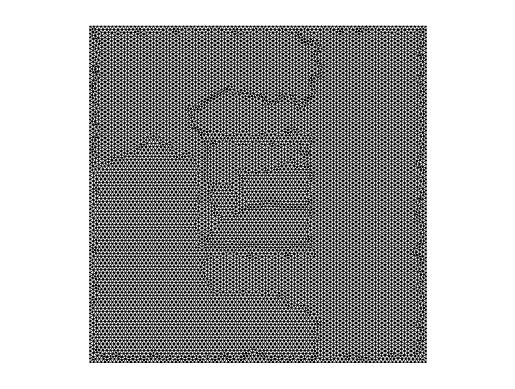

In [84]:
import meshio
from skfem import *
from skfem.helpers import dot, grad
import numpy as np

from skfem.io.meshio import from_meshio

# Add repository root to Python path. Helps to find files and modules
from pathlib import Path
import sys
sys.path.insert(0, str(Path.cwd().parent))


m = meshio.read("mesh/mesh_ex3.msh")

mesh = from_meshio(m)

from skfem.visuals.matplotlib import draw
import matplotlib.pyplot as plt

import matplotlib.tri as mtri

draw(mesh)
plt.axis("equal")
plt.show()

Get triangular elements and first order basis functions. We need to define own basis for each physical group

In [ ]:
from skfem import Basis, ElementTriP1

e = ElementTriP1()
basis = Basis(mesh, e)
basis_core = basis.with_elements(mesh.subdomains["core"])
basis_air = basis.with_elements(mesh.subdomains["air"])
basis_magnet = basis.with_elements(mesh.subdomains["magnet"])

print(basis_core)
print(basis_air)
print(basis_magnet)

<skfem CellBasis(MeshTri1, ElementTriP1) object>
  Number of elements: 1698
  Number of DOFs: 9777
  Size: 366768 B
<skfem CellBasis(MeshTri1, ElementTriP1) object>
  Number of elements: 17008
  Number of DOFs: 9777
  Size: 3673728 B
<skfem CellBasis(MeshTri1, ElementTriP1) object>
  Number of elements: 486
  Number of DOFs: 9777
  Size: 104976 B


Bilinear and linear forms, from weak formulation


In [86]:
# w.mu little coonfusing but it just wraps the permeability to some variable w

@BilinearForm
def laplace(A, v, w):
    return 1/w.mu*dot(grad(A), grad(v))


@LinearForm
def magnet_rhs(v, w):

    Brx = w.Brx
    Bry = w.Bry
    nu = w.nu      # = 1/mu

    return nu * (
        Brx * v.grad[1]
        -
        Bry * v.grad[0]
    )


mu0 = 4 * np.pi * 1e-7

mu_air = mu0
mu_pm = mu0
mu_iron = 1000 * mu0

S_mat = laplace.assemble(basis_air, mu=mu_air)
S_mat += laplace.assemble(basis_magnet, mu=mu_air)
S_mat += laplace.assemble(basis_core, mu=mu_iron)

# Remanent flux. 
Brx = 1.2
Bry = 0

# Magnetization vector [-1, 0] , so  -Bx direction

b = magnet_rhs.assemble(
    basis_magnet,
    Brx=-Brx,
    Bry=Bry,
    nu=1/mu_pm
)


Add Dirichelt BC Az=0 to all boundaries. This models the air as infinitely large volume.

enforce() does the zero BC by default

In [ ]:
S_mat, b = enforce(S_mat, b, D=mesh.boundary_nodes())

Solve & Visualize Az = vector pootential

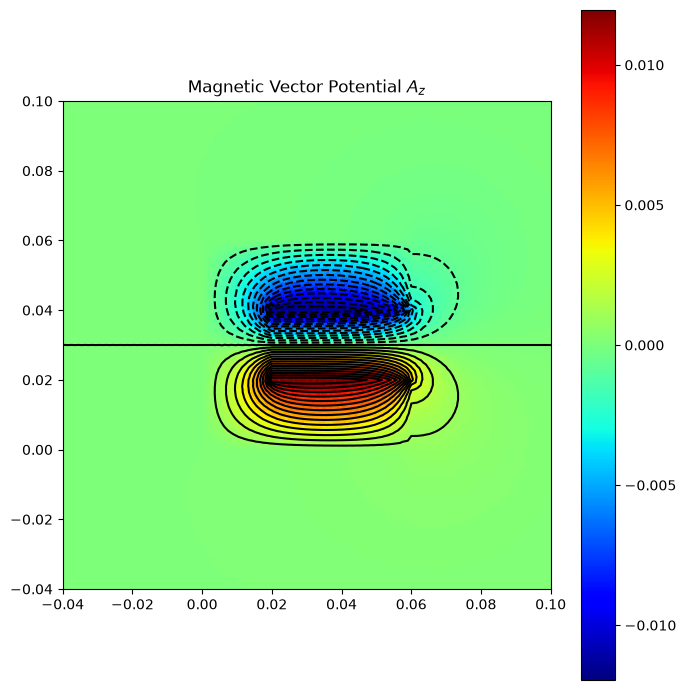

In [89]:
A_z = solve(S_mat, b)



import matplotlib.pyplot as plt
from skfem.visuals.matplotlib import plot


fig, ax = plt.subplots(figsize=(7,7))

plot(
    mesh,
    A_z,
    shading="gouraud",
    colorbar=True,
    ax=ax,
)

plot(
    mesh,
    A_z,
    ax=ax,
    levels=30,
    color="black",
    linewidths=0.4,
)

ax.set_xlim(-0.04,0.1)
ax.set_ylim(-0.04,0.1)

ax.set_aspect("equal")
ax.set_title(r"Magnetic Vector Potential $A_z$")

plt.tight_layout()
#from skfem.visuals.matplotlib import draw

#draw(mesh, ax=ax)

Now we compute Bx and By with partial derivatives to plot B field

In [96]:
# basis.interpolate(A_z) creates a finite element function Ah = sum(Ni*Ai)   ,  where Ni is shape function and Ai is nodal vectorpotential values
uh = basis.interpolate(A_z)

# grad object has the dA/dx and dA/dy components
dAz_dx = uh.grad[0]
dAz_dy = uh.grad[1]

Bx = dAz_dy
By = -dAz_dx

# each quanrature point  has own gradient (P1 elem should have constant gradient) This way we collpase this into one gradient value per element
Bx_elem = Bx.mean(axis=1)
By_elem = By.mean(axis=1)

Bnorm_elem = np.sqrt(Bx_elem**2 + By_elem**2)


(2, 19192)
mesh.p: (2, 9777)
mesh.t: (3, 19192)
centers: (2, 19192)
Bx_plot: (19192,)


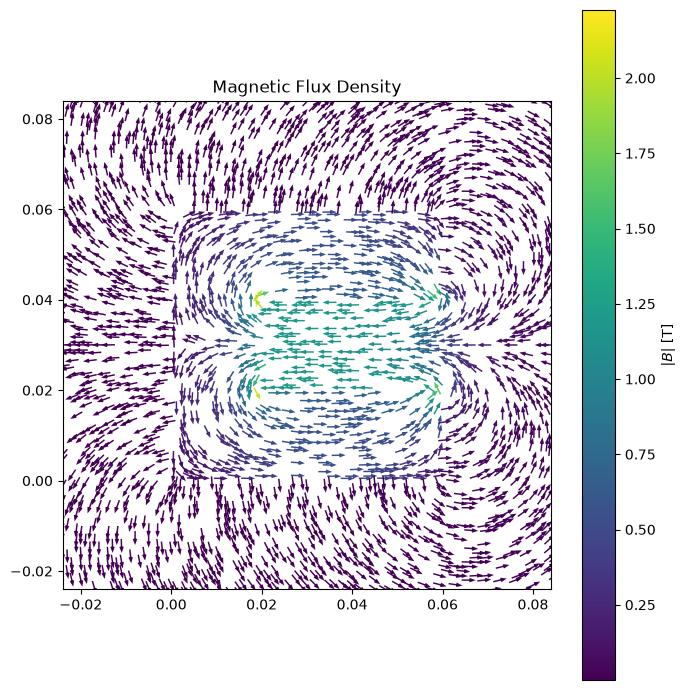

In [97]:
import numpy as np
import matplotlib.pyplot as plt

# Element connectivity
# Coordinates of the three vertices of every element
x = mesh.p[0, mesh.t]   # shape: (3, nelements)
y = mesh.p[1, mesh.t]   # shape: (3, nelements)

# Element centroids
centers = np.vstack([
    x.mean(axis=0),
    y.mean(axis=0)
])

print(centers.shape)


eps = 1e-14

Bx_plot = Bx_elem / (Bnorm_elem + eps)
By_plot = By_elem / (Bnorm_elem + eps)

fig, ax = plt.subplots(figsize=(7,7))

step = 3
print("mesh.p:", mesh.p.shape)
print("mesh.t:", mesh.t.shape)
print("centers:", centers.shape)
print("Bx_plot:", Bx_plot.shape)
q = ax.quiver(
    centers[0][::step],
    centers[1][::step],
    Bx_plot[::step],
    By_plot[::step],
    Bnorm_elem[::step],
    cmap="viridis",
    pivot="mid",
    scale=35,
    width=0.003,
    headwidth=3,
    headlength=4
)

fig.colorbar(q, ax=ax, label=r"$|B|$ [T]")

# Zoom into the region around the C-core
xmin, ymin = mesh.p.min(axis=1)
xmax, ymax = mesh.p.max(axis=1)
d = max(xmax - xmin, ymax - ymin)

margin = 0.2 * d  # CHANGE TO ZOOM

ax.set_xlim(xmin + margin, xmax - margin)
ax.set_ylim(ymin + margin, ymax - margin)

ax.set_aspect("equal")

ax.set_title("Magnetic Flux Density")

plt.tight_layout()

Compute B for each node instead of element. 

#### Plotting B for each node

The gradient is constant in P1 elementents, and is not continious over elements. We have to do some averaging, if node that shares multiple elements have different gradient values.


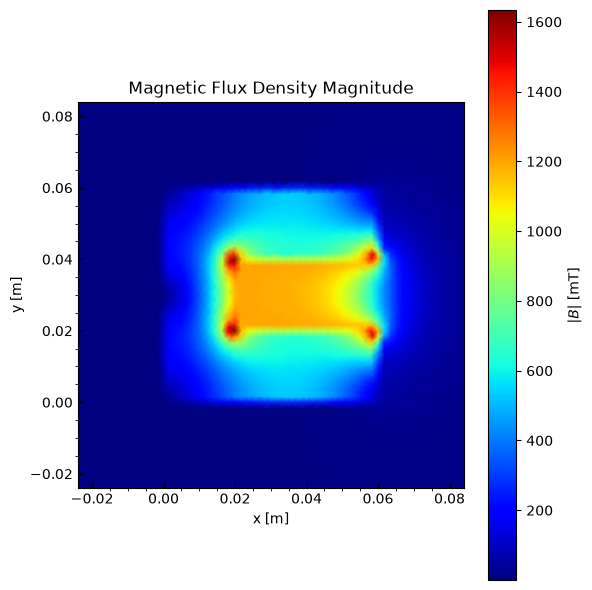

In [98]:
import matplotlib.pyplot as plt
import matplotlib.tri as mtri


triang = mtri.Triangulation(
    mesh.p[0],
    mesh.p[1],
    mesh.t.T
)

# convert element values to nodal values
Bnorm_node = np.zeros(mesh.p.shape[1])
count = np.zeros(mesh.p.shape[1])

for elem, tri in enumerate(mesh.t.T):
    for node in tri:
        Bnorm_node[node] += Bnorm_elem[elem]
        count[node] += 1

# B is constant over each element. Nodal values require averaging
Bnorm_node /= count

fig, ax = plt.subplots(figsize=(6, 6))

plot(
    mesh,
    1000 * Bnorm_node,
    ax=ax,
    shading='gouraud',
    colorbar=True
)

# Zoom into the region around the C-core
xmin, ymin = mesh.p.min(axis=1)
xmax, ymax = mesh.p.max(axis=1)
d = max(xmax - xmin, ymax - ymin)
margin = 0.2 * d  # CHANGE TO ZOOM
ax.set_xlim(xmin + margin, xmax - margin)
ax.set_ylim(ymin + margin, ymax - margin)

ax.set_title("Magnetic Flux Density Magnitude")
ax.set_xlabel("x [m]")
ax.set_ylabel("y [m]")
ax.set_aspect("equal")

ax.tick_params(direction='in')
ax.minorticks_on()

# Label the colorbar
cbar = fig.axes[-1]
cbar.set_ylabel(r"$|B|$ [mT]")

fig.tight_layout()
#draw(mesh, ax=ax)

plt.show()
    

Verify results point-wise against COMSOL 

In [102]:
import numpy as np

# Skip all comment lines starting with %
data = np.loadtxt(
    "verification/A_field",
    comments="%"
)

# Split columns
points = data[:, :2]      # (N,2)
Az_comsol = data[:, 2]    # (N,)


In [103]:
from utils.field_verification import compare_point_values

compare_point_values(
    basis,
    A_z,
    points,
    Az_comsol,
    quantity_name="A_z"
)

      x       y            FEM      Reference     Abs. Error   Rel. Error %
--------------------------------------------------------------------------------
 -0.050 -0.050   1.447145e-06   1.376883e-06   7.026149e-08          5.103
 -0.030 -0.050   5.029567e-06   4.785197e-06   2.443697e-07          5.107
 -0.010 -0.050   1.076623e-05   1.024250e-05   5.237249e-07          5.113
  0.010 -0.050   1.996310e-05   1.898599e-05   9.771090e-07          5.146
  0.030 -0.050   3.261153e-05   3.100676e-05   1.604768e-06          5.176
  0.050 -0.050   4.503694e-05   4.284473e-05   2.192210e-06          5.117
  0.070 -0.050   4.803062e-05   4.574818e-05   2.282440e-06          4.989
  0.090 -0.050   3.542899e-05   3.378209e-05   1.646895e-06          4.875
  0.110 -0.050   1.267231e-05   1.208951e-05   5.828054e-07          4.821
 -0.050 -0.030   3.688735e-06   3.509607e-06   1.791275e-07          5.104
 -0.030 -0.030   1.296538e-05   1.233706e-05   6.283167e-07          5.093
 -0.010 -0.030   2

(array([ 1.44714482e-06,  5.02956681e-06,  1.07662281e-05,  1.99630995e-05,
         3.26115290e-05,  4.50369433e-05,  4.80306202e-05,  3.54289877e-05,
         1.26723108e-05,  3.68873467e-06,  1.29653785e-05,  2.86968217e-05,
         5.60606003e-05,  9.70594683e-05,  1.45358267e-04,  1.63397195e-04,
         1.16802023e-04,  3.99708232e-05,  4.15839318e-06,  1.46944147e-05,
         3.40417175e-05,  7.79625907e-05,  1.48803186e-04,  2.68299343e-04,
         3.68140153e-04,  2.21492061e-04,  6.59860574e-05,  2.62604186e-06,
         9.02890292e-06,  1.82660449e-05,  1.90878103e-03,  5.71041383e-03,
         4.58141407e-03,  9.08588524e-04,  2.71601715e-04,  6.23272372e-05,
        -5.70207244e-08, -1.92059756e-07, -3.63576995e-07, -1.35682205e-04,
        -4.75593113e-04, -4.04118815e-04, -6.17454983e-05, -8.59691057e-06,
        -1.56697156e-06, -2.71548092e-06, -9.35727673e-06, -1.90534823e-05,
        -1.78043189e-03, -5.24652723e-03, -4.18634051e-03, -8.77848264e-04,
        -2.7

In [ ]:
# Skip all comment lines starting with %
data = np.loadtxt(
    "verification/B_field",
    comments="%"
)

# Split columns
points = data[:, :2]      # (N,2)
B_comsol = data[:, 2]    # (N,)

from utils.field_verification import compare_point_values

compare_point_values(
    basis,
    Bnorm_node,
    points,
    B_comsol,
    quantity_name="B_field"
);


      x       y            FEM      Reference     Abs. Error   Rel. Error %
--------------------------------------------------------------------------------
 -0.050 -0.050   2.055258e-04   1.947989e-04   1.072693e-05          5.507
 -0.030 -0.050   5.332424e-04   5.067339e-04   2.650858e-05          5.231
 -0.010 -0.050   1.109821e-03   1.055132e-03   5.468886e-05          5.183
  0.010 -0.050   2.044006e-03   1.942953e-03   1.010526e-04          5.201
  0.030 -0.050   3.330440e-03   3.165442e-03   1.649976e-04          5.212
  0.050 -0.050   4.608638e-03   4.383170e-03   2.254681e-04          5.144
  0.070 -0.050   4.948134e-03   4.712235e-03   2.358993e-04          5.006
  0.090 -0.050   3.754631e-03   3.578408e-03   1.762226e-04          4.925
  0.110 -0.050   1.799479e-03   1.710611e-03   8.886834e-05          5.195
 -0.050 -0.030   3.905366e-04   3.714798e-04   1.905682e-05          5.130
 -0.030 -0.030   6.403843e-04   6.090504e-04   3.133386e-05          5.145
 -0.010 -0.030   1

(array([2.05525786e-04, 5.33242432e-04, 1.10982061e-03, 2.04400610e-03,
        3.33043972e-03, 4.60863823e-03, 4.94813448e-03, 3.75463056e-03,
        1.79947930e-03, 3.90536621e-04, 6.40384273e-04, 1.23596629e-03,
        2.30224877e-03, 3.87508632e-03, 5.95479969e-03, 7.03133731e-03,
        5.76556489e-03, 4.22841502e-03, 4.34735436e-04, 6.78771683e-04,
        1.43319400e-03, 2.93280479e-03, 4.73524790e-03, 9.88337079e-03,
        1.55715540e-02, 1.02268385e-02, 6.87384698e-03, 2.98555968e-04,
        5.66377280e-04, 1.10730430e-03, 2.69510240e-01, 5.80570999e-01,
        5.20733781e-01, 5.91072774e-02, 1.70372834e-02, 7.05236132e-03,
        1.43754062e-04, 4.80365154e-04, 9.08240680e-04, 3.43688540e-01,
        1.19027666e+00, 1.01386892e+00, 1.45396524e-01, 2.07521873e-02,
        4.06589870e-03, 2.99126717e-04, 5.66464359e-04, 1.10638429e-03,
        2.70065838e-01, 5.80331728e-01, 5.20404412e-01, 5.91234240e-02,
        1.70391902e-02, 7.05229452e-03, 4.34671004e-04, 6.788611